# Input Configuration Evaluation: FHR-only vs FHR+UC

This notebook compares two signal input configurations (FHR-only vs FHR+UC) for 3-class CTG classification
using the same model architecture and grouped 10-fold cross-validation.

## 1. Imports

In [53]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
from pathlib import Path
import wfdb
import json
import warnings
from typing import Dict, List, Tuple, Optional

from scipy.interpolate import interp1d

from sklearn.metrics import (
    confusion_matrix, f1_score, accuracy_score,
    balanced_accuracy_score, precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, MaxPooling1D, Dropout, GlobalAveragePooling1D,
    Dense, Reshape, Multiply, Add, Flatten, Concatenate,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
)
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import seaborn as sns

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

StratifiedGroupKFold available.
TensorFlow 2.16.1 | NumPy 1.26.4
GPU available: False


## 2. Configuration

In [54]:
RAW_DATASET  = Path("../data/raw_dataset")
STEP2_LABELS = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS = Path("../ExpertAnnotations/step3_labels.csv")
OUTPUT_ROOT  = Path("outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

In [55]:
RAW_SAMPLING_RATE    = 4
TARGET_SAMPLING_RATE = 1
DOWNSAMPLE_FACTOR    = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE
WINDOW_MINUTES       = 30
WINDOW_LENGTH        = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE
SAMPLING_RATE        = TARGET_SAMPLING_RATE
SEGMENT_MINUTES      = WINDOW_MINUTES
SEGMENT_LENGTH       = WINDOW_LENGTH

In [56]:
NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

In [57]:
CFG = dict(
    step_numbers            = [2, 3],
    mode_a_offsets          = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes         = SEGMENT_MINUTES,
    segment_length          = SEGMENT_LENGTH,
    max_nan_fraction        = 0.16,
    pad_short_records       = False,
    n_splits                = 10,
    cv_seed                 = 42,
    min_severe_records      = 10,
    max_cv_attempts         = 100,
    temporal_filters        = 32,
    separable_filters       = 32,
    separable_kernels       = [3, 7, 15],
    projection_filters      = 32,
    dropout_rate            = 0.40,
    use_clinical_features   = False,
    oversample_severe       = False,
    severe_boost            = 0.0,
    augment_train           = True,
    aug_time_warp           = True,
    aug_warp_sigma          = 0.10,
    aug_amplitude_scale     = True,
    aug_amp_sigma           = 0.10,
    aug_noise               = True,
    aug_noise_std           = 0.02,
    aug_signal_loss         = True,
    aug_gap_frac            = 0.05,
    aug_n_gaps              = 2,
    scratch_epochs          = 100,
    scratch_lr              = 1e-3,
    scratch_batch           = 16,
    scratch_patience        = 20,
    label_smoothing         = 0.05,
    use_class_weights       = True,
)

INPUT_COMPARISON_RUNS = [
    {
        'run_name': 'FHR-only',
        'include_uc': False,
        'n_signal_channels': 1,
        'output_subdir': 'fhr_only',
    },
    {
        'run_name': 'FHR+UC',
        'include_uc': True,
        'n_signal_channels': 2,
        'output_subdir': 'fhr_and_uc',
    },
]

windows_per_step = {s: len(v) for s, v in CFG['controlled_step_offsets'].items()}
CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))

print("Configuration loaded.")
print(f"  Segment length: {CFG['segment_length']} samples ({CFG['segment_minutes']} min)")
print(f"  CV folds: {CFG['n_splits']} | Controlled windows/step: {CONTROLLED_WINDOWS_PER_STEP}")
print(f"  Experiments: {[r['run_name'] for r in INPUT_COMPARISON_RUNS]}")

Configuration loaded.
  Segment length: 1800 samples (30 min)
  CV folds: 10 | Controlled windows/step: 3
  Experiments: ['FHR-only', 'FHR+UC']


## 3. Multimodal Data Loading

In [58]:
def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:
    step_labels = {}
    for step_num, path in step_paths.items():
        df = pd.read_csv(path)
        total = len(df)
        df = df[df['Majority_Vote_Label'] != -1].copy()
        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)
        df['rec_id'] = df['rec_id'].astype(str)
        excluded = total - len(df)
        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")
        for cls_id, name in enumerate(CLASS_NAMES):
            n = int((df['class_id'] == cls_id).sum())
            print(f"  Class {cls_id} ({name}): {n}")
        step_labels[step_num] = df
    return step_labels

In [59]:
def trim_aligned_recording(fhr_signal: list, uc_signal: list) -> Tuple[list, list]:
    last_nonzero = -1
    for i in range(len(fhr_signal) - 1, -1, -1):
        if fhr_signal[i] != 0:
            last_nonzero = i
            break
    if last_nonzero < 0:
        return [], []
    return fhr_signal[:last_nonzero + 1], uc_signal[:last_nonzero + 1]

In [60]:
def clean_aligned_fhr_uc(
    fhr_array,
    uc_array,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray]:
    fhr = pd.Series(np.array(fhr_array, dtype=float))
    fhr.replace(0, np.nan, inplace=True)
    na = fhr.isnull()
    gap_groups = na.ne(na.shift()).cumsum()
    gap_sizes = fhr.groupby(gap_groups.values).transform('size')
    keep_mask = ~(gap_sizes.ge(fs * 15 + 1) & na)
    fhr = fhr[keep_mask].reset_index(drop=True)
    uc = pd.Series(np.array(uc_array, dtype=float))[keep_mask].reset_index(drop=True)

    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan
    fhr = fhr.interpolate(method='linear')
    diff = fhr - fhr.shift()
    fhr[(diff > 25) | (diff < -25)] = np.nan
    fhr = fhr.interpolate(method='linear').ffill().bfill()

    uc_clean = pd.Series(np.array(uc, dtype=float)).ffill().bfill().fillna(0.0)

    return fhr.values, uc_clean.values

In [61]:
def load_raw_signals_multimodal(dataset_path: Path) -> Dict[str, dict]:
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files in {dataset_path}")
    data = {}
    for rid in sorted(records):
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            p_signal = rec.p_signal
            if p_signal.shape[1] < 2:
                print(f"  Skipping {rid}: fewer than 2 channels")
                continue
            fhr_raw = p_signal[:, 0].tolist()
            uc_raw  = p_signal[:, 1].tolist()
            fhr_trimmed, uc_trimmed = trim_aligned_recording(fhr_raw, uc_raw)
            if not fhr_trimmed:
                print(f"  Skipping {rid}: no non-zero FHR samples")
                continue
            fhr_clean, uc_clean = clean_aligned_fhr_uc(fhr_trimmed, uc_trimmed, fs=RAW_SAMPLING_RATE)
            min_len = min(len(fhr_clean), len(uc_clean))
            fhr_clean = fhr_clean[:min_len]
            uc_clean  = uc_clean[:min_len]
            fhr_ds = fhr_clean[::DOWNSAMPLE_FACTOR].astype(np.float32)
            uc_ds  = uc_clean[::DOWNSAMPLE_FACTOR].astype(np.float32)
            data[rid] = {'FHR': fhr_ds, 'UC': uc_ds, 'length': len(fhr_ds)}
        except Exception as e:
            print(f"  Skipping {rid}: {e}")
    print(f"Loaded {len(data)} FHR+UC signals")
    return data

In [62]:
def _window_bounds_from_end(
    sig_len: int,
    offsets_from_end_min: Tuple[int, int],
    fs: int = 4,
) -> Optional[Tuple[int, int]]:
    start_from_end_min, end_from_end_min = offsets_from_end_min
    if start_from_end_min <= end_from_end_min:
        raise ValueError(f"Expected start offset > end offset, got {offsets_from_end_min}")
    start_from_end = start_from_end_min * 60 * fs
    end_from_end = end_from_end_min * 60 * fs
    if sig_len < start_from_end:
        return None
    start_idx = sig_len - start_from_end
    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len
    if end_idx <= start_idx:
        return None
    return int(start_idx), int(end_idx)

In [63]:
def _get_controlled_window_bounds(
    sig_len: int,
    step_num: int,
    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],
    fs: int = 4,
) -> Optional[List[Tuple]]:
    if step_num not in controlled_step_offsets:
        raise KeyError(f"Missing controlled offsets for step {step_num}")
    bounds = []
    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):
        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)
        if cur_bounds is None:
            return None
        start_idx, end_idx = cur_bounds
        bounds.append((window_index, offsets, start_idx, end_idx))
    return bounds

In [64]:
def create_step_windows_multimodal(
    signal_data: Dict[str, dict],
    step_label_dfs: Dict[int, pd.DataFrame],
    record_ids: List[str],
    window_length: int = 7200,
    step_numbers: Optional[List[int]] = None,
    step_offsets: Optional[Dict[int, Tuple[int, int]]] = None,
    controlled_step_offsets: Optional[Dict[int, List[Tuple[int, int]]]] = None,
    max_nan_fraction: float = 0.16,
    pad_short_records: bool = False,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    if step_numbers is None:
        step_numbers = [2, 3]
    if step_offsets is None:
        step_offsets = {2: (60, 30), 3: (30, 0)}
    if controlled_step_offsets is None:
        controlled_step_offsets = {s: [step_offsets[s]] for s in step_numbers}

    X_fhr_list, X_uc_list, y_list, group_list, meta_list = [], [], [], [], []
    accepted = 0
    skipped_short = 0
    skipped_nan = 0

    for rid in record_ids:
        if rid not in signal_data:
            continue
        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)
        uc  = np.array(signal_data[rid]['UC'], dtype=np.float64)
        sig_len = len(fhr)

        for step_num in step_numbers:
            step_df = step_label_dfs.get(step_num)
            if step_df is None:
                continue
            row = step_df[step_df['rec_id'] == rid]
            if row.empty:
                continue

            controlled_bounds = _get_controlled_window_bounds(
                sig_len, step_num, controlled_step_offsets, fs=fs
            )
            if controlled_bounds is None:
                skipped_short += 1
                continue

            label = int(row['class_id'].iloc[0])
            step_windows_fhr = []
            step_windows_uc = []
            failed = False

            for window_index, offsets, start_idx, end_idx in controlled_bounds:
                fhr_win = fhr[start_idx:end_idx]
                uc_win  = uc[start_idx:end_idx]
                if len(fhr_win) < window_length:
                    if pad_short_records:
                        pad_len = window_length - len(fhr_win)
                        fhr_win = np.pad(fhr_win, (pad_len, 0), mode='edge')
                        uc_win  = np.pad(uc_win, (pad_len, 0), mode='edge')
                    else:
                        failed = True
                        skipped_short += 1
                        break
                missing_frac = float(np.mean(np.isnan(fhr_win) | (fhr_win == 0)))
                if missing_frac > max_nan_fraction:
                    failed = True
                    skipped_nan += 1
                    break
                if np.any(np.isnan(fhr_win)):
                    fhr_win = pd.Series(fhr_win).interpolate(method='linear').ffill().bfill().values
                if np.any(np.isnan(uc_win)):
                    uc_win = pd.Series(uc_win).ffill().bfill().fillna(0.0).values
                step_windows_fhr.append(fhr_win[:window_length].astype(np.float32))
                step_windows_uc.append(uc_win[:window_length].astype(np.float32))
                meta_list.append({
                    'rec_id': rid, 'step': step_num,
                    'window_index': window_index,
                    'offset_start_min': int(offsets[0]),
                    'offset_end_min': int(offsets[1]),
                    'label': label,
                    'missing_frac_fhr': missing_frac,
                })

            if failed:
                meta_list = meta_list[:-len(step_windows_fhr)]
                continue

            accepted += 1
            for fhr_win, uc_win in zip(step_windows_fhr, step_windows_uc):
                X_fhr_list.append(fhr_win)
                X_uc_list.append(uc_win)
                y_list.append(label)
                group_list.append(rid)

    n = len(X_fhr_list)
    X_fhr = np.array(X_fhr_list, dtype=np.float32)[:, :, np.newaxis] if n > 0 else np.empty((0, window_length, 1))
    X_uc  = np.array(X_uc_list, dtype=np.float32)[:, :, np.newaxis] if n > 0 else np.empty((0, window_length, 1))
    y     = np.array(y_list, dtype=np.int32)
    groups = np.array(group_list)
    metadata = pd.DataFrame(meta_list)

    print(f"Multimodal window extraction: {n} windows from {len(set(group_list))} records")
    print(f"  Accepted: {accepted} | Skipped short: {skipped_short} | Skipped NaN: {skipped_nan}")
    for cls_id, name in enumerate(CLASS_NAMES):
        print(f"  Class {cls_id} ({name}): {int(np.sum(y == cls_id))} windows")
    return X_fhr, X_uc, y, groups, metadata

In [65]:
STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}
step_label_dfs = load_step_labels(STEP_LABEL_PATHS)
signal_data = load_raw_signals_multimodal(RAW_DATASET)

labelled_rec_ids = set()
for df in step_label_dfs.values():
    labelled_rec_ids.update(df['rec_id'].tolist())

valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))
print(f"Records with Step 2/3 label and FHR+UC signal: {len(valid_rec_ids)}")

Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229
  Class 1 (Mild): 251
  Class 2 (Severe): 68
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127
  Class 1 (Mild): 153
  Class 2 (Severe): 57
Found 552 .hea files in ..\data\raw_dataset
Loaded 552 FHR+UC signals
Records with Step 2/3 label and FHR+UC signal: 549


In [66]:
print("Extracting Step 2 + Step 3 controlled 30-minute windows (FHR + UC)...")
X_fhr_all, X_uc_all, y_all, groups_all, meta_all = create_step_windows_multimodal(
    signal_data=signal_data,
    step_label_dfs=step_label_dfs,
    record_ids=valid_rec_ids,
    window_length=CFG['segment_length'],
    step_numbers=CFG['step_numbers'],
    step_offsets=CFG['mode_a_offsets'],
    controlled_step_offsets=CFG['controlled_step_offsets'],
    max_nan_fraction=CFG['max_nan_fraction'],
    pad_short_records=CFG['pad_short_records'],
    fs=SAMPLING_RATE,
)
print(f"FHR shape: {X_fhr_all.shape} | UC shape: {X_uc_all.shape}")

Extracting Step 2 + Step 3 controlled 30-minute windows (FHR + UC)...
Multimodal window extraction: 1398 windows from 336 records
  Accepted: 466 | Skipped short: 419 | Skipped NaN: 0
  Class 0 (Normal): 564 windows
  Class 1 (Mild): 636 windows
  Class 2 (Severe): 198 windows
FHR shape: (1398, 1800, 1) | UC shape: (1398, 1800, 1)


## 4. Signal Tensor Builder

In [67]:
def build_signal_tensor(
    X_fhr: np.ndarray,
    X_uc: np.ndarray,
    include_uc: bool,
) -> np.ndarray:
    if include_uc:
        return np.concatenate([X_fhr, X_uc], axis=-1).astype(np.float32)
    return X_fhr.astype(np.float32)

## 5. Normalization and Augmentation

In [68]:
def compute_norm_stats_multichannel(X_train: np.ndarray) -> dict:
    n_channels = X_train.shape[-1]
    stats = {}
    for c in range(n_channels):
        channel_vals = X_train[:, :, c].ravel()
        mean = float(np.mean(channel_vals))
        std  = float(np.std(channel_vals))
        if std < 1e-8:
            std = 1.0
        stats[c] = {'mean': mean, 'std': std}
    return stats

In [69]:
def apply_norm_multichannel(X: np.ndarray, stats: dict) -> np.ndarray:
    X_norm = X.astype(np.float32).copy()
    for c, channel_stats in stats.items():
        X_norm[:, :, c] -= channel_stats['mean']
        X_norm[:, :, c] /= channel_stats['std']
    return X_norm

In [70]:
def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    N, T, C = X.shape
    X_warped = np.empty_like(X)
    orig_steps = np.arange(T)
    n_knots = 4
    knot_pos = np.linspace(0, T - 1, n_knots + 2)
    for i in range(N):
        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)
        warp_factors[0] = 1.0
        warp_factors[-1] = 1.0
        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])
        warped_knots = np.concatenate([[0], warped_knots])
        warped_knots = warped_knots / warped_knots[-1] * (T - 1)
        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')
        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)
        for c in range(C):
            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')
            X_warped[i, :, c] = interp_sig(warped_steps)
    return X_warped.astype(np.float32)

In [71]:
def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    scales = np.random.normal(1.0, sigma, size=(X.shape[0], 1, 1)).astype(np.float32)
    return X * scales

In [72]:
def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:
    return X + np.random.normal(0, noise_std, X.shape).astype(np.float32)

In [73]:
def signal_loss_simulation(X: np.ndarray, max_gap_frac: float = 0.05, n_gaps: int = 2) -> np.ndarray:
    N, T, C = X.shape
    X_aug = X.copy()
    max_gap = max(1, int(T * max_gap_frac))
    for i in range(N):
        for _ in range(n_gaps):
            gap_len = np.random.randint(1, max_gap + 1)
            start = np.random.randint(0, T - gap_len)
            end = start + gap_len
            for c in range(C):
                left_val = X_aug[i, max(start - 1, 0), c]
                right_val = X_aug[i, min(end, T - 1), c]
                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)
    return X_aug.astype(np.float32)

In [74]:
def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:
    X_aug = X.copy()
    if cfg.get('aug_time_warp', True):
        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))
    if cfg.get('aug_amplitude_scale', True):
        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))
    if cfg.get('aug_noise', True):
        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))
    if cfg.get('aug_signal_loss', True):
        X_aug = signal_loss_simulation(
            X_aug,
            max_gap_frac=cfg.get('aug_gap_frac', 0.05),
            n_gaps=cfg.get('aug_n_gaps', 2),
        )
    return X_aug

## 6. Multimodal Model Architecture

Hybrid Multi-Scale CNN that accepts a configurable number of input channels to accommodate both FHR-only
and FHR+UC experiments.

In [75]:
def _se_block_1d(x, filters: int, reduction: int = 8):
    se = GlobalAveragePooling1D()(x)
    se = Dense(max(1, filters // reduction), activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, filters))(se)
    return Multiply()([x, se])

In [76]:
def build_model_multimodal(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = NUM_CLASSES,
    n_signal_channels: int = 1,
    temporal_filters: int = 32,
    separable_filters: int = 32,
    separable_kernels: Optional[List[int]] = None,
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
) -> Model:
    if separable_kernels is None:
        separable_kernels = [3, 7, 15]

    signal_input = Input(shape=(input_length, n_signal_channels), name="signal_input")

    x = Conv1D(temporal_filters, 7, padding='same', use_bias=False, name='temporal_conv')(signal_input)
    x = BatchNormalization(name='temporal_bn')(x)
    x = Activation('relu', name='temporal_relu')(x)
    x = MaxPooling1D(4, name='temporal_pool')(x)
    x = Dropout(dropout_rate * 0.5, name='temporal_drop')(x)

    branches = []
    for k in separable_kernels:
        b = SeparableConv1D(separable_filters, k, padding='same', use_bias=False)(x)
        b = BatchNormalization()(b)
        b = Activation('relu')(b)
        b = _se_block_1d(b, separable_filters)
        branches.append(b)

    if len(branches) > 1:
        x_merged = Add()(branches) if all(b.shape == branches[0].shape for b in branches) else Concatenate()(branches)
        x_merged = Conv1D(projection_filters, 1, padding='same', use_bias=False, name='proj')(x_merged)
        x_merged = BatchNormalization(name='proj_bn')(x_merged)
        x_merged = Activation('relu', name='proj_relu')(x_merged)
    else:
        x_merged = branches[0]

    residual = Conv1D(projection_filters, 1, padding='same', use_bias=False, name='res_skip')(x)
    x_out = Add(name='residual_add')([x_merged, residual])
    x_out = Dropout(dropout_rate, name='final_drop')(x_out)
    x_out = GlobalAveragePooling1D(name='gap')(x_out)

    outputs = Dense(num_classes, activation='softmax', name='output')(x_out)
    model_name = f"MultiScale-CNN-{n_signal_channels}ch"
    return Model(signal_input, outputs, name=model_name)

## 7. Training Functions

In [77]:
def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta

In [78]:
def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    meta = _ensure_step_keys(metadata)
    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one label")
    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)

In [79]:
def resolve_min_severe_threshold(
    metadata: pd.DataFrame,
    n_splits: int,
    requested_min: int = 10,
    severe_class: int = 2,
) -> Tuple[int, int, int]:
    step_targets = build_step_target_table(metadata.reset_index(drop=True))
    step_y = step_targets['label'].to_numpy(dtype=int)
    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0
    effective_min = requested_min
    if effective_min > min_possible:
        effective_min = max(min_possible - 1, 1) if total_severe > 0 else 0
        print(f"  WARNING: Requested >= {requested_min} Severe step-units/fold is infeasible; using {effective_min}.")
    return effective_min, total_severe, min_possible

In [80]:
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return {int(c): float(w) for c, w in zip(classes, weights)}

In [81]:
class RecordStepBalancedAccuracy(Callback):
    def __init__(self, X_val, val_metadata, batch_size=32):
        super().__init__()
        self.X_val = X_val
        self.val_metadata = _ensure_step_keys(val_metadata.reset_index(drop=True))
        self.batch_size = batch_size

    def _aggregate(self, y_proba):
        step_y_true, step_y_pred = [], []
        for step_key in self.val_metadata['step_key'].unique():
            mask = self.val_metadata['step_key'] == step_key
            mean_proba = y_proba[mask].mean(axis=0)
            step_y_true.append(int(self.val_metadata.loc[mask, 'label'].iloc[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))
        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        del epoch
        logs = logs or {}
        y_proba = self.model.predict(self.X_val, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")

In [82]:
def get_callbacks(patience, monitor, monitor_mode, save_path=None) -> list:
    callbacks = [
        EarlyStopping(
            monitor=monitor, mode=monitor_mode,
            patience=patience, restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor, mode=monitor_mode,
            factor=0.5, patience=max(patience // 2, 3),
            min_lr=1e-6, verbose=1,
        ),
    ]
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path, monitor=monitor, mode=monitor_mode,
            save_best_only=True, save_weights_only=True, verbose=0,
        ))
    return callbacks

In [83]:
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 10,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], int]:
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)
    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    effective_min, total_severe, min_possible = resolve_min_severe_threshold(
        meta, n_splits=n_splits, requested_min=min_severe_records, severe_class=severe_class,
    )
    print(f"  Total Severe step-units: {total_severe}, {n_splits} folds -> max ~{min_possible}/fold")

    best_folds = None
    best_min_severe = -1

    for attempt in range(max_attempts):
        seed = cv_seed + attempt
        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids   = set(step_targets.iloc[val_step_idx]['rec_id'])
            n_severe = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_severe)
            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask   = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))
            if n_severe < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds

        if all_ok:
            print(f"  Valid split at attempt {attempt + 1}: Severe per fold: {fold_severe_counts}")
            return candidate_folds, effective_min

    print(f"  WARNING: Could not meet >= {effective_min} Severe/fold. Best: {best_min_severe}")
    return best_folds, effective_min

In [84]:
def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)
    step_counts = {
        cls_id: int(np.sum(step_targets['label'].to_numpy(dtype=int) == cls_id))
        for cls_id in range(NUM_CLASSES)
    }
    window_counts = {
        cls_id: int(np.sum(val_meta['label'].to_numpy(dtype=int) == cls_id))
        for cls_id in range(NUM_CLASSES)
    }
    n_severe = step_counts.get(severe_class, 0)
    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_severe,
        is_reliable=(n_severe >= min_severe_records),
    )
    return stats['is_reliable'], stats

In [85]:
def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true, step_y_pred = [], []
    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))
    return unique_step_keys, np.array(step_y_true, dtype=int), np.array(step_y_pred, dtype=int)

In [86]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    labels = list(range(NUM_CLASSES))
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    metrics = {'accuracy': acc, 'balanced_accuracy': bal_acc, 'macro_f1': macro_f1, 'confusion_matrix': cm}
    for i, name in enumerate(CLASS_NAMES):
        metrics[f'precision_{name}'] = float(precision[i])
        metrics[f'recall_{name}'] = float(recall[i])
        metrics[f'f1_{name}'] = float(f1[i])
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0
    return metrics

In [87]:
def print_metrics(metrics: dict, prefix: str = "") -> None:
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")

## 8. Input-Variant Cross-Validation

The same grouped folds are reused for both experiments to ensure a fair comparison with no data leakage.

In [88]:
def run_grouped_cv_input_variant(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    run_name: str,
    n_signal_channels: int,
    output_dir: Path,
    shared_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None,
    effective_min_severe: int = 10,
    manual_class_weights: Optional[dict] = None,
) -> List[dict]:
    output_dir.mkdir(parents=True, exist_ok=True)
    metadata = _ensure_step_keys(metadata.reset_index(drop=True))
    n_splits = cfg['n_splits']

    if shared_folds is None:
        shared_folds, effective_min_severe = stratified_record_kfold_with_constraint(
            metadata,
            n_splits=n_splits,
            min_severe_records=cfg.get('min_severe_records', 10),
            max_attempts=cfg.get('max_cv_attempts', 100),
            cv_seed=cfg['cv_seed'],
        )

    fold_results = []
    all_step_y_true, all_step_y_pred = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(shared_folds):
        print(f"\n[{run_name}] Fold {fold_idx + 1} / {n_splits}")

        is_reliable, val_stats = analyze_validation_set(
            metadata, val_idx, min_severe_records=effective_min_severe,
        )

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        assert len(set(g_train) & set(g_val)) == 0, "DATA LEAKAGE"
        print(f"  Train: {len(X_train)} windows | Val: {len(X_val)} windows")

        norm_stats = compute_norm_stats_multichannel(X_train)
        X_train_n  = apply_norm_multichannel(X_train, norm_stats)
        X_val_n    = apply_norm_multichannel(X_val, norm_stats)

        tf.keras.backend.clear_session()
        model = build_model_multimodal(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            n_signal_channels=n_signal_channels,
            temporal_filters=cfg.get('temporal_filters', 32),
            separable_filters=cfg.get('separable_filters', 32),
            separable_kernels=cfg.get('separable_kernels', [3, 7, 15]),
            projection_filters=cfg.get('projection_filters', 32),
            dropout_rate=cfg.get('dropout_rate', 0.40),
        )

        if manual_class_weights is not None:
            cw = {int(k): float(v) for k, v in manual_class_weights.items()}
        else:
            cw = compute_class_weights_from_y(y_train)

        label_smoothing = float(cfg.get('label_smoothing', 0.0))
        model.compile(
            optimizer=Adam(learning_rate=cfg['scratch_lr']),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
            metrics=['accuracy'],
        )

        X_train_aug = augment_signal(X_train_n, cfg) if cfg.get('augment_train', False) else X_train_n.copy()
        y_train_cat = to_categorical(y_train, NUM_CLASSES)
        y_val_cat   = to_categorical(y_val, NUM_CLASSES)

        save_path = str(output_dir / f"fold{fold_idx + 1}_best.weights.h5")
        monitor_callback = RecordStepBalancedAccuracy(
            X_val=X_val_n, val_metadata=meta_val, batch_size=32,
        )
        model.fit(
            X_train_aug, y_train_cat,
            validation_data=(X_val_n, y_val_cat),
            epochs=cfg['scratch_epochs'],
            batch_size=cfg['scratch_batch'],
            class_weight=cw,
            callbacks=[monitor_callback] + get_callbacks(
                patience=cfg['scratch_patience'],
                monitor='val_record_step_balanced_accuracy',
                monitor_mode='max',
                save_path=save_path,
            ),
            verbose=1,
        )

        y_proba = model.predict(X_val_n, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        fold_results.append(metrics)
        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        print_metrics(metrics, prefix=f"[{run_name}] Fold {fold_idx + 1} ")

    print(f"\n[{run_name}] Summary:")
    for key in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        vals = [r[key] for r in fold_results]
        print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    _plot_cm(overall_cm, title=f"{run_name} Overall CM", save_path=output_dir / "overall_cm.png")
    _plot_fold_bar(fold_results, run_name, save_path=output_dir / "fold_summary.png")

    return fold_results

## 9. Visualisation

In [89]:
def _plot_cm(cm: np.ndarray, title: str = "Confusion Matrix", save_path=None) -> None:
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(str(save_path), dpi=150, bbox_inches='tight')
    plt.show()

In [90]:
def _plot_fold_bar(fold_results: List[dict], run_name: str, save_path=None) -> None:
    f1s = [r['macro_f1'] for r in fold_results]
    folds = list(range(1, len(f1s) + 1))
    _, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(np.mean(f1s), color='red', linestyle='--', label=f"Mean = {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}")
    ax.set_title(f"{run_name} - Per-Fold Macro F1", fontsize=14)
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(str(save_path), dpi=150, bbox_inches='tight')
    plt.show()

In [91]:
def build_experiment_summary(
    run_cfg: dict,
    fold_results: List[dict],
    global_cfg: dict,
) -> dict:
    return {
        'run_name': run_cfg['run_name'],
        'include_uc': run_cfg['include_uc'],
        'n_signal_channels': run_cfg['n_signal_channels'],
        'n_folds': len(fold_results),
        'n_reliable_folds': sum(1 for r in fold_results if r.get('is_reliable', True)),
        'window_length': global_cfg['segment_length'],
        'mean_macro_f1': float(np.mean([r['macro_f1'] for r in fold_results])),
        'std_macro_f1': float(np.std([r['macro_f1'] for r in fold_results])),
        'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in fold_results])),
        'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in fold_results])),
        'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in fold_results])),
        'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in fold_results])),
        'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in fold_results])),
        'per_fold': [{k: v for k, v in r.items() if k != 'confusion_matrix'} for r in fold_results],
    }

## 10. Run Experiments

Runs both FHR-only and FHR+UC experiments sharing the same folds for a directly comparable evaluation.

In [92]:
print("Pre-computing shared cross-validation folds...")
shared_folds, effective_min_severe = stratified_record_kfold_with_constraint(
    meta_all,
    n_splits=CFG['n_splits'],
    min_severe_records=CFG['min_severe_records'],
    max_attempts=CFG['max_cv_attempts'],
    cv_seed=CFG['cv_seed'],
)
print(f"Shared folds computed: {len(shared_folds)} folds, effective min Severe = {effective_min_severe}")

Pre-computing shared cross-validation folds...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Valid split at attempt 8: Severe per fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Shared folds computed: 10 folds, effective min Severe = 5



EXPERIMENT: FHR-only  (channels=1)
Input tensor shape: (1398, 1800, 1)

[FHR-only] Fold 1 / 10
  Train: 1254 windows | Val: 144 windows

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4813 - loss: 1.3043  val_record_step_balanced_accuracy: 0.3333
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.4848 - loss: 1.3270 - val_accuracy: 0.3611 - val_loss: 1.0983 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5090 - loss: 1.2526  val_record_step_balanced_accuracy: 0.3333
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4952 - loss: 1.2911 - val_accuracy: 0.3611 - val_loss: 1.1105 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5122 - loss: 1.2373  val_record_step_balanced_accuracy: 0.3333
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5048 - loss: 1.2798 - val_accuracy: 0.3750 - val_los

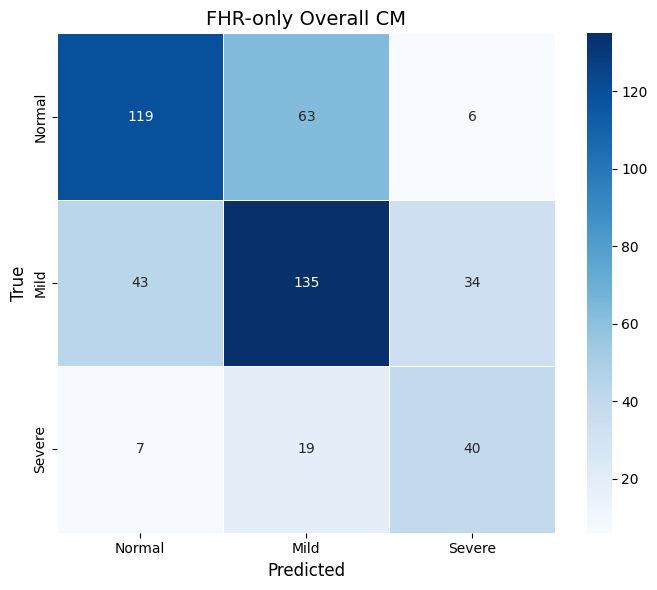

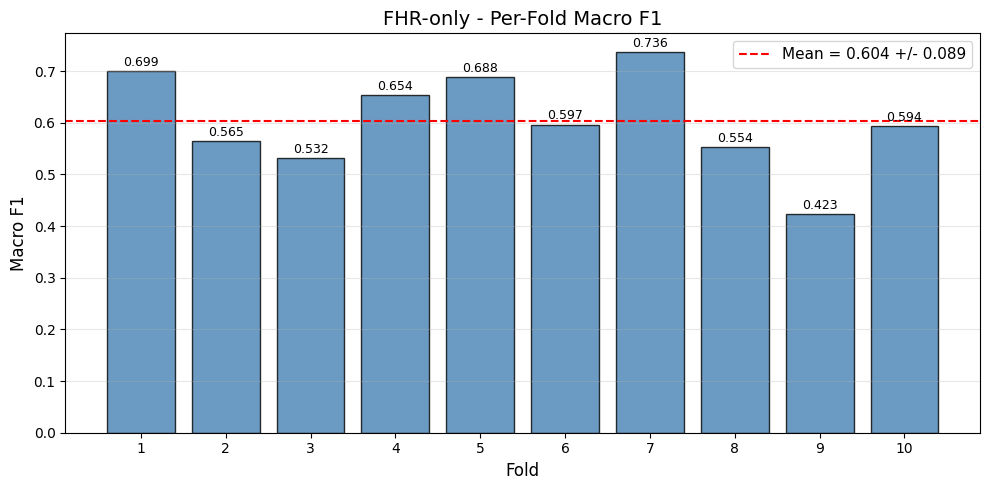


Results for 'FHR-only' saved to outputs\fhr_only

EXPERIMENT: FHR+UC  (channels=2)
Input tensor shape: (1398, 1800, 2)

[FHR+UC] Fold 1 / 10
  Train: 1254 windows | Val: 144 windows
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4672 - loss: 1.3399  val_record_step_balanced_accuracy: 0.4426
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - accuracy: 0.4753 - loss: 1.3457 - val_accuracy: 0.2778 - val_loss: 1.1700 - val_record_step_balanced_accuracy: 0.4426 - learning_rate: 0.0010
Epoch 2/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5042 - loss: 1.2656  val_record_step_balanced_accuracy: 0.3782
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.4952 - loss: 1.3019 - val_accuracy: 0.3056 - val_loss: 1.1699 - val_record_step_balanced_accuracy: 0.3782 - learning_rate: 0.0010
Epoch 3/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5388 - loss: 1.2363  val_record_step_balanced_accuracy: 0.3585
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.5175 -

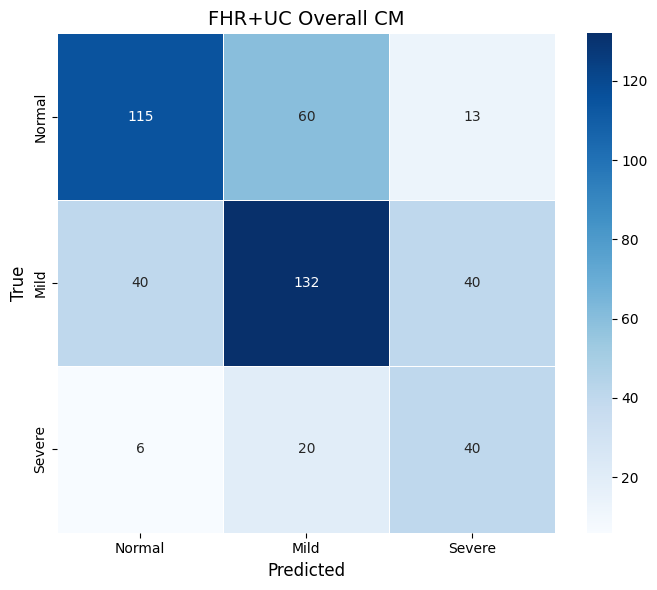

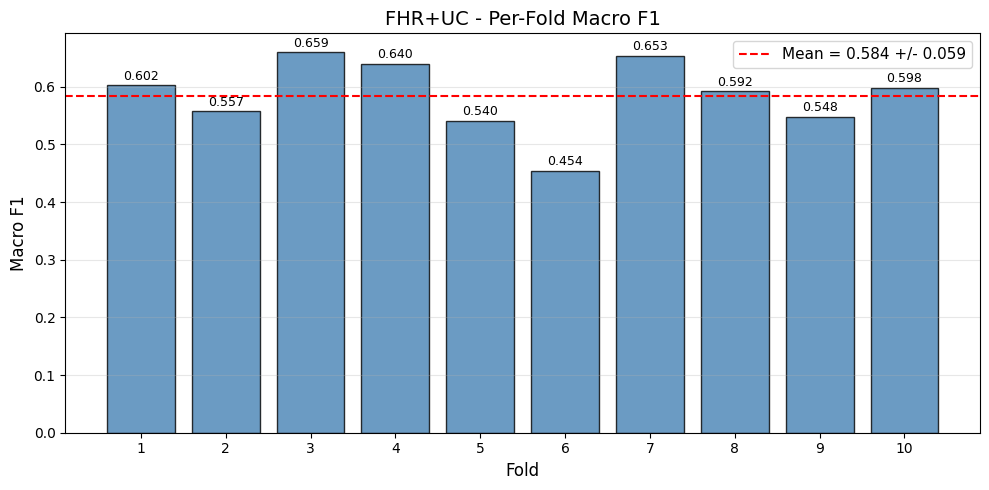


Results for 'FHR+UC' saved to outputs\fhr_and_uc

All input evaluation experiments complete.


In [93]:
MANUAL_CLASS_WEIGHTS = {0: 0.9, 1: 1.2, 2: 2.5}
ALL_EXPERIMENT_RESULTS = {}

for run_cfg in INPUT_COMPARISON_RUNS:
    run_name       = run_cfg['run_name']
    include_uc     = run_cfg['include_uc']
    n_channels     = run_cfg['n_signal_channels']
    output_subdir  = OUTPUT_ROOT / run_cfg['output_subdir']

    print("\n" + "=" * 70)
    print(f"EXPERIMENT: {run_name}  (channels={n_channels})")
    print("=" * 70)

    X_run = build_signal_tensor(X_fhr_all, X_uc_all, include_uc=include_uc)
    print(f"Input tensor shape: {X_run.shape}")

    fold_results = run_grouped_cv_input_variant(
        X=X_run,
        y=y_all,
        groups=groups_all,
        metadata=meta_all,
        cfg=CFG,
        run_name=run_name,
        n_signal_channels=n_channels,
        output_dir=output_subdir,
        shared_folds=shared_folds,
        effective_min_severe=effective_min_severe,
        manual_class_weights=MANUAL_CLASS_WEIGHTS,
    )

    summary = build_experiment_summary(run_cfg, fold_results, CFG)
    ALL_EXPERIMENT_RESULTS[run_name] = {'summary': summary, 'fold_results': fold_results}

    with open(output_subdir / f"{run_cfg['output_subdir']}_results.json", 'w') as f:
        json.dump(summary, f, indent=2, default=str)
    print(f"\nResults for '{run_name}' saved to {output_subdir}")

print("\nAll input evaluation experiments complete.")

## 11. Results Comparison

In [94]:
def _fmt(vals):
    return f"{np.mean(vals):.4f} +/- {np.std(vals):.4f}"

print("=" * 70)
print("INPUT ABLATION STUDY - FINAL COMPARISON")
print("=" * 70)
print(f"{'Metric':<25} {'FHR-only':>20} {'FHR+UC':>20}")
print("-" * 70)

metrics_to_compare = [
    ('Macro F1', 'macro_f1'),
    ('Balanced Accuracy', 'balanced_accuracy'),
    ('Accuracy', 'accuracy'),
    ('Recall - Normal', 'recall_Normal'),
    ('Recall - Mild', 'recall_Mild'),
    ('Recall - Severe', 'recall_Severe'),
]

for label, key in metrics_to_compare:
    row = f"  {label:<23}"
    for run_name in ['FHR-only', 'FHR+UC']:
        if run_name in ALL_EXPERIMENT_RESULTS:
            vals = [r[key] for r in ALL_EXPERIMENT_RESULTS[run_name]['fold_results']]
            row += f" {_fmt(vals):>20}"
        else:
            row += f" {'N/A':>20}"
    print(row)

print("="*70)
print("Reliable folds per experiment:")
for run_name in ['FHR-only', 'FHR+UC']:
    if run_name in ALL_EXPERIMENT_RESULTS:
        n_rel = ALL_EXPERIMENT_RESULTS[run_name]['summary']['n_reliable_folds']
        print(f"  {run_name}: {n_rel} / {CFG['n_splits']}")

INPUT ABLATION STUDY - FINAL COMPARISON
Metric                                FHR-only               FHR+UC
----------------------------------------------------------------------
  Macro F1                   0.6041 +/- 0.0886    0.5843 +/- 0.0592
  Balanced Accuracy          0.6177 +/- 0.0774    0.6097 +/- 0.0735
  Accuracy                   0.6324 +/- 0.0732    0.6184 +/- 0.0505
  Recall - Normal            0.6308 +/- 0.1636    0.6171 +/- 0.1602
  Recall - Mild              0.6253 +/- 0.2110    0.6165 +/- 0.1659
  Recall - Severe            0.5970 +/- 0.1548    0.5955 +/- 0.1831
Reliable folds per experiment:
  FHR-only: 10 / 10
  FHR+UC: 10 / 10


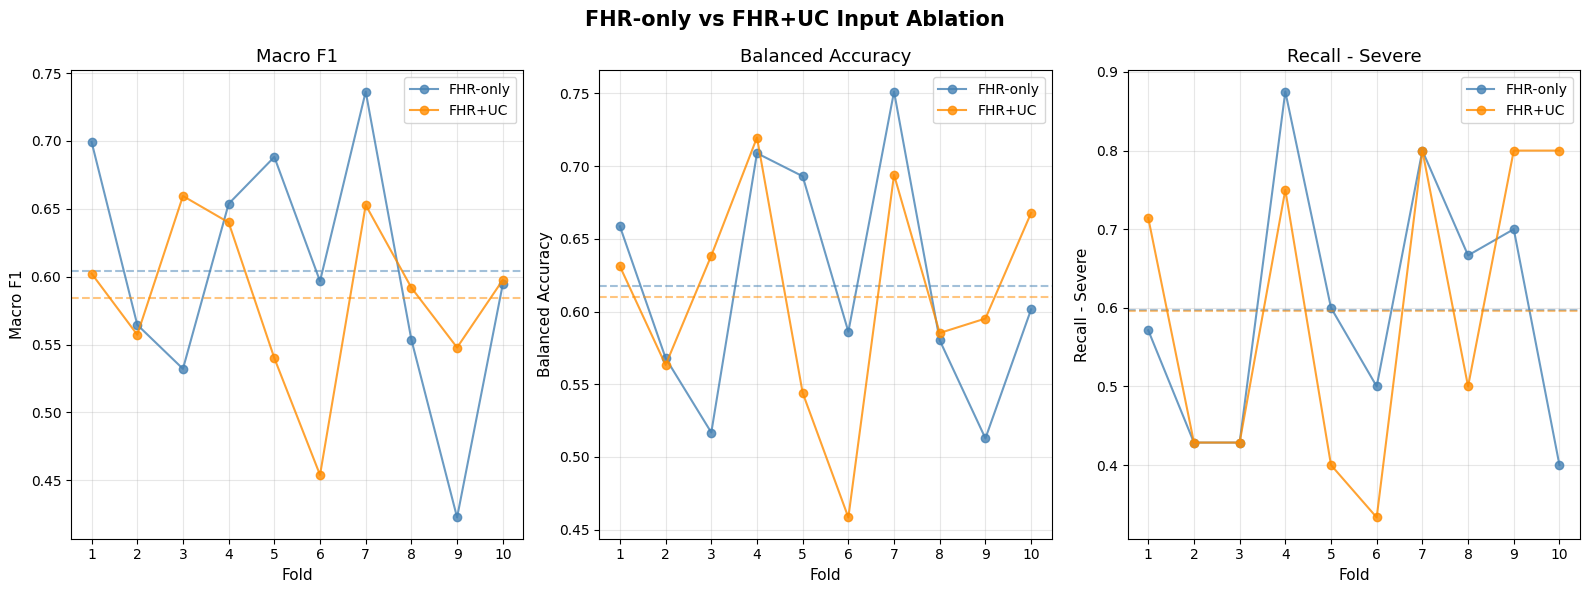

In [95]:
run_names = list(ALL_EXPERIMENT_RESULTS.keys())
if len(run_names) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    metric_keys = [('Macro F1', 'macro_f1'), ('Balanced Accuracy', 'balanced_accuracy'), ('Recall - Severe', 'recall_Severe')]
    colors = ['steelblue', 'darkorange']

    for ax, (metric_label, metric_key) in zip(axes, metric_keys):
        for rn, color in zip(run_names, colors):
            if rn not in ALL_EXPERIMENT_RESULTS:
                continue
            vals = [r[metric_key] for r in ALL_EXPERIMENT_RESULTS[rn]['fold_results']]
            folds = list(range(1, len(vals) + 1))
            ax.plot(folds, vals, marker='o', label=rn, color=color, alpha=0.8)
            ax.axhline(np.mean(vals), linestyle='--', color=color, alpha=0.5)

        ax.set_title(metric_label, fontsize=13)
        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_xticks(list(range(1, CFG['n_splits'] + 1)))
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

    plt.suptitle('FHR-only vs FHR+UC Input Ablation', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_ROOT / "input_ablation_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()

In [96]:
comparison_rows = []
for run_name, data in ALL_EXPERIMENT_RESULTS.items():
    s = data['summary']
    comparison_rows.append({
        'Input Configuration': run_name,
        'N Channels': s['n_signal_channels'],
        'Macro F1': f"{s['mean_macro_f1']:.4f} +/- {s['std_macro_f1']:.4f}",
        'Balanced Accuracy': f"{s['mean_balanced_acc']:.4f} +/- {s['std_balanced_acc']:.4f}",
        'Recall Normal': f"{s['mean_recall_Normal']:.4f}",
        'Recall Mild': f"{s['mean_recall_Mild']:.4f}",
        'Recall Severe': f"{s['mean_recall_Severe']:.4f}",
        'Reliable Folds': f"{s['n_reliable_folds']}/{s['n_folds']}",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUT_ROOT / "input_ablation_summary.csv", index=False)
print("Input ablation summary saved.")
print(comparison_df.to_string(index=False))

Input ablation summary saved.
Input Configuration  N Channels          Macro F1 Balanced Accuracy Recall Normal Recall Mild Recall Severe Reliable Folds
           FHR-only           1 0.6041 +/- 0.0886 0.6177 +/- 0.0774        0.6308      0.6253        0.5970          10/10
             FHR+UC           2 0.5843 +/- 0.0592 0.6097 +/- 0.0735        0.6171      0.6165        0.5955          10/10
